In [1]:
import os
import glob
import random
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [2]:
from pathlib import Path

# TODO: set this correctly for your dataset slug
DATA_DIR = Path(
    "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data"
)

h5_files = sorted(DATA_DIR.glob("*.h5"))
print("Total h5 slice files:", len(h5_files))
print("Example file:", h5_files[0])

Total h5 slice files: 57195
Example file: /kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_0.h5


In [3]:
import h5py

def inspect_h5(path):
    with h5py.File(path, "r") as f:
        keys = list(f.keys())
        print("Keys:", keys)
        for k in keys:
            arr = f[k][...]
            print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

inspect_h5(h5_files[0])

Keys: ['image', 'mask']
image: shape=(240, 240, 4), dtype=float64
mask: shape=(240, 240, 3), dtype=uint8


In [4]:
# Set these according to the inspection above
IMG_KEY = "image"  # or "data", etc.
MASK_KEY = "mask"  # or "label", etc.

def load_slice(h5_path):
    with h5py.File(h5_path, "r") as f:
        img = f["image"][...]   # (240, 240, 4)
        mask = f["mask"][...]   # (240, 240, 3)

    img = np.asarray(img, dtype=np.float32)   # (H, W, 4)
    mask = np.asarray(mask, dtype=np.uint8)   # (H, W, 3)

    # --- IMAGE: (H, W, 4) -> leave as is, we'll normalize per channel later ---
    # if you want, assert:
    # assert img.ndim == 3 and img.shape[-1] == 4

    # --- MASK: (H, W, 3) -> (H, W) labels in {0,1,2,3} ---
    m = mask.astype(np.float32)

    # If it's 0/255, binarize to 0/1
    if m.max() > 1.0:
        m = (m > 0).astype(np.float32)

    # m: (H, W, 3) assumed one-hot for 3 tumor classes; build background channel
    bg = (m.sum(axis=-1, keepdims=True) == 0).astype(np.float32)  # (H, W, 1)
    one_hot = np.concatenate([bg, m], axis=-1)                    # (H, W, 4)

    label = np.argmax(one_hot, axis=-1).astype(np.int64)          # (H, W), 0..3

    return img, label

def normalize_image(img):
    """
    Per-slice z-score per channel.
    img: (H, W, C)
    """
    img = img.astype(np.float32)
    for c in range(img.shape[-1]):
        ch = img[..., c]
        m = ch.mean()
        s = ch.std() + 1e-8
        img[..., c] = (ch - m) / s
    return img

In [5]:
class BratsSliceDataset(Dataset):
    def __init__(self, h5_paths, augment=False):
        self.h5_paths = list(h5_paths)
        self.augment = augment

    def __len__(self):
        return len(self.h5_paths)

    def __getitem__(self, idx):
        path = self.h5_paths[idx]
        img, mask = load_slice(path)
        img = normalize_image(img)

        # ----- Augmentations -----
        if self.augment:
            if random.random() < 0.5:
                img = np.flip(img, axis=1)
                mask = np.flip(mask, axis=1)
            if random.random() < 0.5:
                img = np.flip(img, axis=0)
                mask = np.flip(mask, axis=0)

        # IMPORTANT: remove negative strides from flips
        img = img.copy()
        mask = mask.copy()

        # Map labels {0,1,2,3} already handled in load_slice, so just convert
        img = np.transpose(img, (2, 0, 1))  # (C, H, W)
        img = torch.from_numpy(img).float()
        mask = torch.from_numpy(mask).long()

        return img, mask

In [6]:
# Optional: subsample for faster debug
MAX_FILES = None  # e.g. 30000 for quicker prototyping
all_files = h5_files
if MAX_FILES is not None and MAX_FILES < len(all_files):
    all_files = random.sample(all_files, MAX_FILES)

print("Using", len(all_files), "slice files")

random.shuffle(all_files)
n_total = len(all_files)
n_train = int(0.8 * n_total)
train_files = all_files[:n_train]
val_files = all_files[n_train:]

train_dataset = BratsSliceDataset(train_files, augment=True)
val_dataset   = BratsSliceDataset(val_files,   augment=False)

BATCH_SIZE = 32  # increase if GPU has room
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# Quick sanity check batch
xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)  # (B, C, H, W)
print("Batch mask shape:", yb.shape)   # (B, H, W)

Using 57195 slice files
Train samples: 45756
Val samples: 11439
Batch image shape: torch.Size([32, 4, 240, 240])
Batch mask shape: torch.Size([32, 240, 240])


In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=4, n_classes=4, base_ch=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base_ch)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch, base_ch*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch*2, base_ch*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch*4, base_ch*8))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch*8, base_ch*8))

        self.up1 = nn.ConvTranspose2d(base_ch*8, base_ch*8, 2, stride=2)
        self.conv1 = DoubleConv(base_ch*16, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, stride=2)
        self.conv2 = DoubleConv(base_ch*8, base_ch*2)
        self.up3 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, stride=2)
        self.conv3 = DoubleConv(base_ch*4, base_ch)
        self.up4 = nn.ConvTranspose2d(base_ch, base_ch, 2, stride=2)
        self.conv4 = DoubleConv(base_ch*2, base_ch)

        self.outc = nn.Conv2d(base_ch, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x = self.conv1(torch.cat([x, x4], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x3], dim=1))
        x = self.up3(x)
        x = self.conv3(torch.cat([x, x2], dim=1))
        x = self.up4(x)
        x = self.conv4(torch.cat([x, x1], dim=1))
        logits = self.outc(x)
        return logits

# infer channels
sample_x, _ = train_dataset[0]
in_channels = sample_x.shape[0]
print("Input channels:", in_channels)

model = UNet2D(in_ch=in_channels, n_classes=4, base_ch=32).to(device)
print("Model params (M):", sum(p.numel() for p in model.parameters())/1e6)

Input channels: 4
Model params (M): 3.6993


In [8]:
class DiceLossMulti(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        inter = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)
        dice = (2. * inter + self.smooth) / (cardinality + self.smooth)
        return 1. - dice.mean()

def dice_coefficient(logits, targets, ignore_background=True):
    num_classes = logits.shape[1]
    preds = torch.argmax(logits, dim=1)

    dices = []
    for c in range(num_classes):
        if ignore_background and c == 0:
            continue
        p = (preds == c).float()
        t = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum()
        if union == 0:
            continue
        d = (2 * inter + 1e-5) / (union + 1e-5)
        dices.append(d.item())
    if not dices:
        return 0.0
    return sum(dices) / len(dices)

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLossMulti()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/1437142383.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=True):
            logits = model(x)
            loss_ce = ce_loss(logits, y)
            loss_d = dice_loss(logits, y)
            loss = loss_ce + loss_d

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    return running_loss / len(train_loader)

@torch.no_grad()
def evaluate():
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    count = 0

    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=True):
            logits = model(x)
            loss_ce = ce_loss(logits, y)
            loss_d = dice_loss(logits, y)
            loss = loss_ce + loss_d

        val_loss += loss.item()
        val_dice += dice_coefficient(logits, y, ignore_background=True)
        count += 1

    return val_loss / count, val_dice / count

In [13]:
EPOCHS = 20  # you can increase if time allows

best_dice = 0.0
best_path = "best_unet_brats_slices.pth"

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(epoch)
    val_loss, val_dice = evaluate()
    scheduler.step()

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_dice_fg={val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), best_path)
        print(f">>> New best Dice (fg): {best_dice:.4f} – model saved")

print("Best validation Dice (foreground classes):", best_dice)

/tmp/ipykernel_55/4218013058.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


Epoch 1 | Batch 0/1430 | Loss: 0.2321
Epoch 1 | Batch 100/1430 | Loss: 0.2517
Epoch 1 | Batch 200/1430 | Loss: 0.3348
Epoch 1 | Batch 300/1430 | Loss: 0.3100
Epoch 1 | Batch 400/1430 | Loss: 0.1990
Epoch 1 | Batch 500/1430 | Loss: 0.2204
Epoch 1 | Batch 600/1430 | Loss: 0.2054
Epoch 1 | Batch 700/1430 | Loss: 0.1653
Epoch 1 | Batch 800/1430 | Loss: 0.1171
Epoch 1 | Batch 900/1430 | Loss: 0.2426
Epoch 1 | Batch 1000/1430 | Loss: 0.2188
Epoch 1 | Batch 1100/1430 | Loss: 0.2041
Epoch 1 | Batch 1200/1430 | Loss: 0.2920
Epoch 1 | Batch 1300/1430 | Loss: 0.2560
Epoch 1 | Batch 1400/1430 | Loss: 0.2685


/tmp/ipykernel_55/4218013058.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


Epoch 1: train_loss=0.2249 | val_loss=0.2068 | val_dice_fg=0.7559
>>> New best Dice (fg): 0.7559 – model saved
Epoch 2 | Batch 0/1430 | Loss: 0.1788
Epoch 2 | Batch 100/1430 | Loss: 0.1485
Epoch 2 | Batch 200/1430 | Loss: 0.1845
Epoch 2 | Batch 300/1430 | Loss: 0.2726
Epoch 2 | Batch 400/1430 | Loss: 0.1456
Epoch 2 | Batch 500/1430 | Loss: 0.1923
Epoch 2 | Batch 600/1430 | Loss: 0.2121
Epoch 2 | Batch 700/1430 | Loss: 0.3741
Epoch 2 | Batch 800/1430 | Loss: 0.1836
Epoch 2 | Batch 900/1430 | Loss: 0.1965
Epoch 2 | Batch 1000/1430 | Loss: 0.2118
Epoch 2 | Batch 1100/1430 | Loss: 0.2015
Epoch 2 | Batch 1200/1430 | Loss: 0.1795
Epoch 2 | Batch 1300/1430 | Loss: 0.2849
Epoch 2 | Batch 1400/1430 | Loss: 0.2270
Epoch 2: train_loss=0.2087 | val_loss=0.2069 | val_dice_fg=0.7561
>>> New best Dice (fg): 0.7561 – model saved
Epoch 3 | Batch 0/1430 | Loss: 0.3061
Epoch 3 | Batch 100/1430 | Loss: 0.2161
Epoch 3 | Batch 200/1430 | Loss: 0.2268
Epoch 3 | Batch 300/1430 | Loss: 0.1331
Epoch 3 | Batch 4

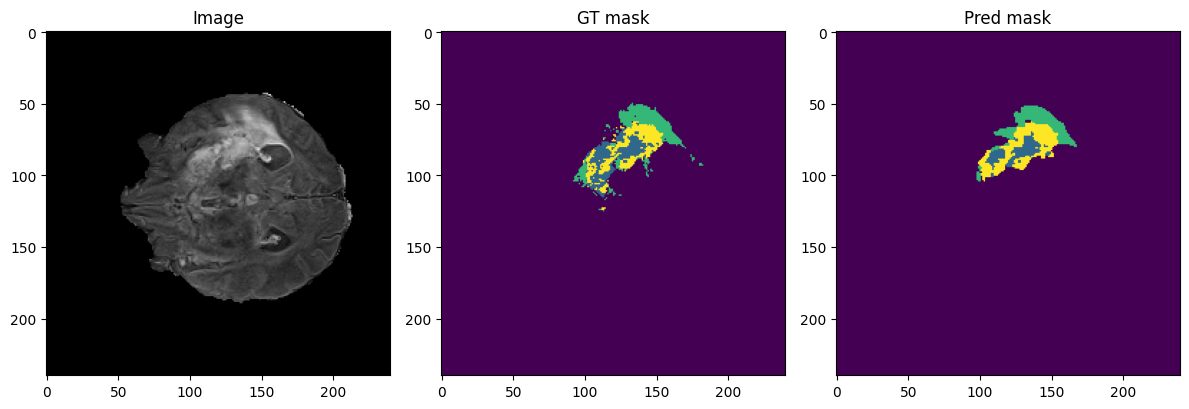

In [14]:
# load best model
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

@torch.no_grad()
def visualize_random_slice(loader):
    x, y = next(iter(loader))
    x = x.to(device)
    logits = model(x)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

    x = x.cpu().numpy()
    y = y.cpu().numpy()

    idx = random.randint(0, x.shape[0] - 1)
    img = x[idx, 0]  # first channel
    gt = y[idx]
    pr = preds[idx]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.title("Image"); plt.imshow(img, cmap="gray")
    plt.subplot(1, 3, 2); plt.title("GT mask"); plt.imshow(gt, cmap="viridis")
    plt.subplot(1, 3, 3); plt.title("Pred mask"); plt.imshow(pr, cmap="viridis")
    plt.tight_layout()
    plt.show()

visualize_random_slice(val_loader)

In [15]:
import torch
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = f"unet_brats_slices_dice_{best_dice:.3f}.pth"
MODEL_PATH = OUTPUT_DIR / MODEL_NAME

torch.save(model.state_dict(), MODEL_PATH)
print("Saved model to:", MODEL_PATH)

Saved model to: /kaggle/working/unet_brats_slices_dice_0.829.pth


In [16]:
import zipfile

file_path = "/kaggle/working/unet_brats_slices_dice_0.829.pth"
zip_path = "/kaggle/working/unet_brats_slices_dice_0.829.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write(file_path, arcname="unet_brats_slices_dice_0.829.pth")

print("Zipped successfully:", zip_path)

Zipped successfully: /kaggle/working/unet_brats_slices_dice_0.829.zip
